Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
速度定数がすべて既知で、初期濃度を与えた場合、各化学種の経時変化をシミュレーションする場合の事例。
ただし、引用文献中の実験による化学種の濃度の経時変化もわかっており、シミュレーション結果にこれを重ね書きした。  
04_example_script_classExpDataFit_ref3.ipynbでは、同じデータからフィッティングにより速度定数を求めており、文献記載の値との比較も可能。  
1. csvに書き込んだ反応式を読み込む。ただし速度定数はすべて既知とする  
2. RxnIVPsolv("sample_data.csv")でインスタンス化し、化学種ごとの微分型の反応速度式を作成する  
3. 作成した微分方程式を、数値解析可能な形式にする  
4. 化学種ごとの濃度の経時変化を求める。数値積分では、get_ode_system()で必要なオブジェクトを取得する。   
5. matplotlibで結果をプロットし、経時変化を図示する  

## 引用文献  
3) Kentaro TAMAKI, Seiichi YADA, Shiro KUDO, Reaction of 3- (1-Naphthyloxy) -2-hydroxy-1-propyltosylate with Isopropylamine, Journal of Synthetic Organic Chemistry, Japan, 1972, Volume 30, Issue 2, Pages 175-178, Released on J-STAGE November 13, 2009, Online ISSN 1883-6526, Print ISSN 0037-9980, https://doi.org/10.5059/yukigoseikyokaishi.30.175, https://www.jstage.jst.go.jp/article/yukigoseikyokaishi1943/30/2/30_2_175/_article/-char/en  

- 文献中表1 アセトニトリル溶媒のデータ、および式 [1] の反応式を用いた。  
- 併発反応と逐次反応が共存する系を例示した。  

## 反応式を記載したcsvファイルを指定する  

In [1]:
# tempolary added for development
import sys, os

project_root = os.getcwd()  # Notebook を開いたディレクトリ
sys.path.append(os.path.join(project_root, "../src"))

In [2]:
file_path = './sample_data/ref3/sample_rxn_ref3AN_litk.csv'  # CSVファイルのパスを指定

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [3]:
import numpy as np
import pandas as pd

from rxnfit import RxnODEbuild, SolverConfig, RxnODEsolver
from rxnfit.expdata_reader import expdata_read


In [4]:
builded_rxnode = RxnODEbuild(file_path)

In [5]:
builded_rxnode.get_ode_info(debug_info=True)

number of species: 3
unique species: ['Tos', 'Prop', 'Nep']
rate constant: {'k1': 0.004, 'k2': 0.009, 'k3': 0.02}

=== debug info ===
Successfully created function for Tos with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Prop with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Nep with args: ['t', 'Tos', 'Prop', 'Nep']
order of args: ['t', 'Tos', 'Prop', 'Nep']
system of ODE: {'Tos': '-1/1*k1*Tos(t)-1/1*k2*Tos(t)', 'Prop': '1/1*k1*Tos(t)+1/1*k3*Nep(t)', 'Nep': '1/1*k2*Tos(t)-1/1*k3*Nep(t)'}


In [6]:
builded_rxnode.rate_consts_dict

{'k1': 0.004, 'k2': 0.009, 'k3': 0.02}

## 数値積分を実行する  

In [7]:
# 各化学種の初期濃度の入力順序を確認する  
builded_rxnode.get_ode_info()

number of species: 3
unique species: ['Tos', 'Prop', 'Nep']
rate constant: {'k1': 0.004, 'k2': 0.009, 'k3': 0.02}


In [8]:
# get_ode_infoの出力を参照して、初期値等の入力項目を渡す
config = SolverConfig(
    y0 = [0.3, 0.0, 0.0], # 初期濃度（必須）
    t_span=(0, 240),         # 時間範囲（必須）
    # t_eval: Optional[np.ndarray] = field(default=None),  # 任意
    method = "LSODA",  # 任意
    rtol = 1e-6,    # 任意    
)

In [9]:
# 基本的な数値積分 -インスタンス化-
solved_rxnode = RxnODEsolver(builded_rxnode, config)

### LSODA / numbalsoda 問題切り分け

`UserWarning: Though the import numbalsoda succeeded, RHS is not supported` は、`solve_ode(..., method="LSODA")` 内で **`system_rhs.numbalsoda_rhs` に numba のネイティブ `.address` が無い** ときに出ます（`solv_ode.py` の `solve_ode(` 行に見えるのは警告の `stacklevel` のため）。

SymPy 1.13 以降は `lambdify(..., modules="numba")` が使えません。rxnfit は **`lambdify(..., modules="numpy")` + `numba.njit`** で RHS を構築します（下のステップ [B]/[B']）。

**上のセルで `config` と `builded_rxnode` を実行したあと**、次のセルを実行してどの段階で失敗しているか確認してください。

In [10]:
# --- LSODA / numbalsoda 問題切り分け（UserWarning: RHS is not supported）---
import importlib.util
import traceback


def _mod_ok(name: str) -> bool:
    return importlib.util.find_spec(name) is not None


print("=== 1) モジュールの有無 ===")
for pkg in ("sympy", "numba", "numbalsoda"):
    print(f"  {pkg}: {'OK' if _mod_ok(pkg) else 'MISSING'}")

print("\n=== 2) numbalsoda と lsoda_sig ===")
try:
    import numbalsoda as _nb  # noqa: F401
    from numbalsoda import lsoda_sig  # noqa: F401

    print("  import numbalsoda / lsoda_sig: OK")
except Exception as e:
    print("  FAILED:", repr(e))
    traceback.print_exc()

print("\n=== 3) numba cfunc / carray ===")
try:
    from numba import cfunc, carray  # noqa: F401

    print("  OK")
except Exception as e:
    print("  FAILED:", repr(e))
    traceback.print_exc()

print("\n=== 4) 時間依存レート（True なら numbalsoda RHS は付かない）===")
from rxnfit.rate_const_ft_eval import has_time_dependent_rates

rcv_cfg = getattr(config, "rate_const_values", None)
td_callable = callable(rcv_cfg)
td_dict = has_time_dependent_rates(builded_rxnode.rate_consts_dict)
print(f"  rate_const_values が callable: {td_callable}")
print(f"  has_time_dependent_rates(rate_consts_dict): {td_dict}")
print(f"  → RxnODEsolver が渡す time_dependent: {td_callable or td_dict}")

print("\n=== 5) solver_backend._load_numbalsoda() ===")
from rxnfit import solver_backend as _sb

_nbmod = _sb._load_numbalsoda()
print("  result:", "OK" if _nbmod is not None else "None (import 失敗)")

print("\n=== 6) SymPy spec / lambdify(numpy)+njit（numbalsoda_rhs と同じ手順）===")
from sympy import lambdify
from numba import njit

try:
    _spec = builded_rxnode.get_numbalsoda_sympy_spec(None, None)
    print("  [A] get_numbalsoda_sympy_spec: OK, n_state=", _spec["n_state"], " n_p=", _spec["n_p"])
except Exception as e:
    print("  [A] FAILED:", e)
    traceback.print_exc()
    _spec = None

if _spec is not None:
    try:
        _np_fn = lambdify(_spec["lambdify_args"], _spec["expr_tuple"], modules="numpy")
        print("  [B] lambdify(..., modules='numpy'): OK")
        _vec_fn = njit(_np_fn)
        print("  [B'] njit(...): OK")
        n_state = int(_spec["n_state"])
        n_p = int(_spec["n_p"])
        _probe = [0.0] + [1.0] * n_state + [0.25] * n_p
        _tpl = _vec_fn(*_probe[: len(_spec["lambdify_args"])])
        print("  [C] vec_fn 試行呼び出し: OK, type=", type(_tpl).__name__)
    except Exception as e:
        print("  [B/C] FAILED（numba と式の組み合わせを確認）:", e)
        traceback.print_exc()

from rxnfit.numbalsoda_rhs import compile_numbalsoda_rhs_for_builder

_out = compile_numbalsoda_rhs_for_builder(builded_rxnode, None, None)
print("  [D] compile_numbalsoda_rhs_for_builder:", _out if _out is None else f"(cfunc, n_p={_out[1]})")

print("\n=== 7) create_system_rhs 直後（solve_system と同じ numb_ctx 想定）===")
from rxnfit.build_ode import create_system_rhs

_td = td_callable or td_dict
_numb_ctx = {
    "builder": builded_rxnode,
    "time_dependent": _td,
    "rate_const_values": rcv_cfg,
    "symbolic_rate_const_keys": getattr(config, "symbolic_rate_const_keys", None),
}
(_, _, _ode_sys, _fnames, _) = builded_rxnode.get_ode_system()
_sr = create_system_rhs(_ode_sys, _fnames, numbalsoda_context=_numb_ctx)
_rhs_nb = getattr(_sr, "numbalsoda_rhs", None)
_addr = getattr(_rhs_nb, "address", None) if _rhs_nb is not None else None
print("  numbalsoda_rhs:", _rhs_nb)
print("  .address:", _addr)
print("  _rxnfit_lsoda_n_p:", getattr(_sr, "_rxnfit_lsoda_n_p", "(unset)"))
if _addr is None:
    print(
        "\n  結論: solve_ode(LSODA) は「Though the import numbalsoda succeeded, RHS is not supported」で RK45 にフォールバックします。"
    )
    print("  上の [A]〜[D] のどこで FAILED したかを確認してください。")
else:
    print("\n  結論: numbalsoda 用 RHS は付与済み。別要因（実行時 lsoda 失敗など）を疑ってください。")

=== 1) モジュールの有無 ===
  sympy: OK
  numba: OK
  numbalsoda: OK

=== 2) numbalsoda と lsoda_sig ===
  import numbalsoda / lsoda_sig: OK

=== 3) numba cfunc / carray ===
  OK

=== 4) 時間依存レート（True なら numbalsoda RHS は付かない）===
  rate_const_values が callable: False
  has_time_dependent_rates(rate_consts_dict): False
  → RxnODEsolver が渡す time_dependent: False

=== 5) solver_backend._load_numbalsoda() ===
  result: OK

=== 6) SymPy spec / lambdify(numba) / コンパイル（失敗段階を特定）===
  [A] get_numbalsoda_sympy_spec: OK, n_state= 3  n_p= 0
  [B/C] FAILED（numba・sympy の組み合わせや式が原因になりがち）: 'numba' module cannot be used for lambdification
  [D] compile_numbalsoda_rhs_for_builder: (cfunc, n_p=0)

=== 7) create_system_rhs 直後（solve_system と同じ numb_ctx 想定）===
Successfully created function for Tos with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Prop with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Nep with args: ['t', 'Tos', 'Prop', 'Nep']
  numbalsoda_rhs: <Numba C cal

Traceback (most recent call last):
  File "/home/mt_oh/work/rxnfit/venv312u/lib/python3.12/site-packages/sympy/utilities/lambdify.py", line 146, in _import
    namespace, namespace_default, translations, import_commands = MODULES[
                                                                  ^^^^^^^^
KeyError: 'numba'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/tmp/ipykernel_16999/2283747494.py", line 62, in <module>
    _vec_fn = lambdify(_spec["lambdify_args"], _spec["expr_tuple"], modules="numba")
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mt_oh/work/rxnfit/venv312u/lib/python3.12/site-packages/sympy/utilities/lambdify.py", line 808, in lambdify
    buf = _get_namespace(m)
          ^^^^^^^^^^^^^^^^^
  File "/home/mt_oh/work/rxnfit/venv312u/lib/python3.12/site-packages/sympy/utilities/lambdify.py", line 971, in _get_namespace
    _import(m)
  File "/home/

In [11]:
ode_construct, sol = solved_rxnode.solve_system()

Successfully created function for Tos with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Prop with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Nep with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Tos with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Prop with args: ['t', 'Tos', 'Prop', 'Nep']
Successfully created function for Nep with args: ['t', 'Tos', 'Prop', 'Nep']


## 経時変化の実験データを読み込み　　
### データフレーム化  

In [12]:
file_path_data = './sample_data/ref3/sample_timecourse_ref3AN.csv' # データファイルのパス
df1 = pd.read_csv(file_path_data)

expdata_read([df1,])  # 複数データフレームのリストを渡すとまとめて読み込み可能

[([array([ 15,  30,  60, 120, 240]),
   array([ 15,  30,  60, 120, 240]),
   array([ 15,  30,  60, 120, 240])],
  [array([0.24, 0.22, 0.13, 0.04, 0.01]),
   array([0.03 , 0.06 , 0.07 , 0.03 , 0.001]),
   array([0.02, 0.05, 0.11, 0.22, 0.27])])]


=== Time-course plot ===


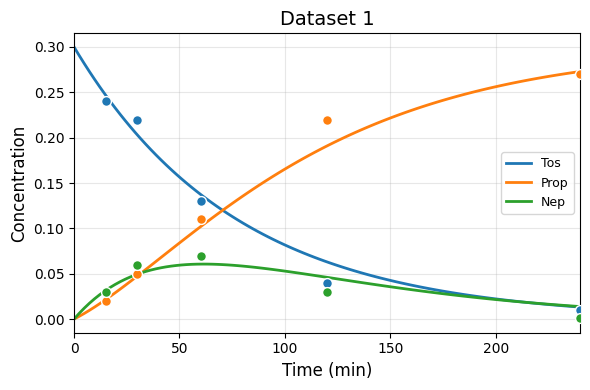


=== Concentration at the final time point ===
Dataset 1:
  Tos: 0.013247
  Prop: 0.272895
  Nep: 0.013858


In [13]:
solved_rxnode.solution_plot(expdata_df=df1)

## 微分方程式の解を数値として表示する  

In [14]:
df_solvd = solved_rxnode.to_dataframe_list(time_column_name="min")[0]
df_solvd

,min,Tos,Prop,Nep
0,0.000000,0.300000,0.000000,0.000000
1,2.424242,0.290693,0.003018,0.006290
2,4.848485,0.281674,0.006240,0.012086
3,7.272727,0.272936,0.009647,0.017417
4,9.696970,0.264469,0.013217,0.022314
...,...,...,...,...
95,230.303030,0.015027,0.269506,0.015467
96,232.727273,0.014561,0.270390,0.015050
97,235.151515,0.014109,0.271248,0.014642
98,237.575758,0.013671,0.272083,0.014245


## 与えた速度定数で解と、実験値の残渣二乗和    
実験の時間で再積分して残差二乗和（表示あり）  

In [15]:
metrics = solved_rxnode.eval_fit_metrics(df1)

Residual sum of squares: 0.014364  R²: 0.844216
